In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import scipy.optimize
import scipy.stats
from scipy.optimize import curve_fit

V band: n=4.042±0.774, μ_e=21.984±0.439, χ²_red=0.093
r band: n=6.585±0.364, μ_e=22.354±0.100, χ²_red=0.196
C band: n=2.799±0.832, μ_e=21.652±0.748, χ²_red=0.404
B band: n=0.368±126.059, μ_e=21.718±273.397, χ²_red=0.010


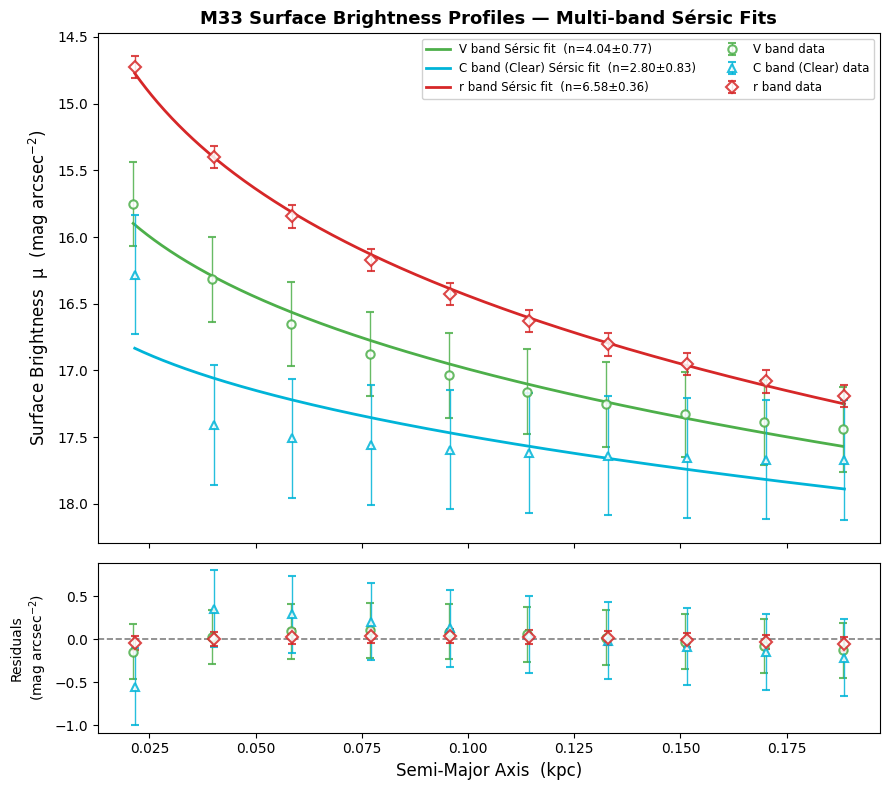

In [20]:

# Sérsic model (shared)

r_e = 3.8
Distance = 840

def c(n):
    return 2.5*(0.868*n - 0.142)

def sersic_model(r, n, Mu_e):
    return Mu_e + c(n)*((r/r_e)**(1/n) - 1)

def fit_band(R_arcsec, C_counts, bg_counts, bg_area_radius, zp, sys_err):
    R = R_arcsec * 0.9117
    D = C_counts - (bg_counts)/(np.pi*bg_area_radius**2) * (R**2 * np.pi)
    M = -2.5*np.log10(D) + zp
    Mu = M + 2.5*np.log10(np.pi*R**2)
    M_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C_counts)/D))**2 + sys_err)
    r = R * Distance / 206265

    initial_guess = [1.0, 24]
    bounds = ([0.1, 20], [10, 30])
    popt, pcov = scipy.optimize.curve_fit(
        sersic_model, r, Mu,
        sigma=M_err, absolute_sigma=True,
        p0=initial_guess, bounds=bounds
    )
    best_n, best_Mu_e = popt
    perr = np.sqrt(np.diag(pcov))
    n_err, Mu_e_err = perr

    model_vals = sersic_model(r, best_n, best_Mu_e)
    chi2 = np.sum(((Mu - model_vals)/M_err)**2)
    dof = len(r) - 2
    chi2_reduced = chi2/dof

    residuals = Mu - model_vals
    r_smooth = np.linspace(np.min(r), np.max(r), 500)
    mu_fit = sersic_model(r_smooth, best_n, best_Mu_e)

    return r, Mu, M_err, residuals, r_smooth, mu_fit, best_n, n_err, best_Mu_e, Mu_e_err, chi2_reduced

# V band

R_V = np.array([5.7,10.7,15.7,20.7,25.7,30.7,35.7,40.7,45.7,50.7])
C_V = np.array([0.49327e6,0.1326e7,0.25072e7,0.40487e7,0.59545e7,0.82233e7,0.10862e8,0.13873e8,0.1725e8,0.20999e8])
res_V = fit_band(R_V, C_V, 0.21117e7, 16.7, 24.582, 0.101)


# r band

R_r = np.array([5.8,10.8,15.8,20.8,25.8,30.8,35.8,40.8,45.8,50.8])
C_r = np.array([0.98538e6,0.20816e7,0.33356e7,0.47910e7,0.6463e7,0.83567e7,0.10478e8,0.12833e8,0.15427e8,0.18264e8])
res_r = fit_band(R_r, C_r, 0.55546e6, 10.1, 24.669, 0.007)


# C band

R_C = np.array([5.8,10.8,15.8,20.8,25.8,30.8,35.8,40.8,45.8,50.8])
C_C = np.array([0.41444e6,0.99232e6,0.20781e7,0.35645e7,0.54458e7,0.77229e7,0.10392e8,0.13456e8,0.16915e8,0.20799e8])
res_C = fit_band(R_C, C_C, 0.30876e7, 20.0, 24.669, 0.2)


# B band

R_B = np.array([5.8,10.8,15.8,20.8,25.8,30.8,35.8,40.8,45.8,50.8])
C_B = np.array([11160,38105,82521,0.14488e6,0.22225e6,0.31581e6,0.42644e6,0.55257e6,0.69507e6,0.85259e6])
res_B = fit_band(R_B, C_B, 91304, 16.7, 24.669, 0.2)


# Print results

for name, res in [('V', res_V), ('r', res_r), ('C', res_C), ('B', res_B)]:
    r, Mu, M_err, residuals, r_smooth, mu_fit, best_n, n_err, best_Mu_e, Mu_e_err, chi2_r = res
    print(f"{name} band: n={best_n:.3f}±{n_err:.3f}, μ_e={best_Mu_e:.3f}±{Mu_e_err:.3f}, χ²_red={chi2_r:.3f}")


# Band colours 
# B=blue, V=green, C=cyan, r=red

bands = {
    
    'V': {'res': res_V, 'color': '#4daf4a', 'marker': 'o', 'label': 'V band'},
    'C': {'res': res_C, 'color': '#00b4d8', 'marker': '^', 'label': 'C band (Clear)'},
    'r': {'res': res_r, 'color': '#d62728', 'marker': 'D', 'label': 'r band'},
}

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

for key, info in bands.items():
    r, Mu, M_err, residuals, r_smooth, mu_fit, best_n, n_err, best_Mu_e, Mu_e_err, chi2_r = info['res']
    col = info['color']
    mk  = info['marker']
    lbl = info['label']

    # Data points
    ax1.errorbar(r, Mu, yerr=M_err,
                 fmt=mk, color=col, markerfacecolor='white',
                 markeredgewidth=1.5, capsize=3, elinewidth=1,
                 alpha=0.85, zorder=3,
                 label=f'{lbl} data')

    # Best-fit line
    ax1.plot(r_smooth, mu_fit,
             color=col, linewidth=2.0, linestyle='-',
             label=f'{lbl} Sérsic fit  (n={best_n:.2f}±{n_err:.2f})')

    # Residuals
    ax2.errorbar(r, residuals, yerr=M_err,
                 fmt=mk, color=col, markerfacecolor='white',
                 markeredgewidth=1.5, capsize=3, elinewidth=1,
                 alpha=0.85, zorder=3)

ax2.axhline(0, color='grey', linestyle='--', linewidth=1.2, zorder=1)

ax1.set_ylabel("Surface Brightness  μ  (mag arcsec$^{-2}$)", fontsize=12)
ax1.invert_yaxis()
ax1.set_title("M33 Surface Brightness Profiles — Multi-band Sérsic Fits", fontsize=13, fontweight='bold')
ax1.legend(fontsize=8.5, ncol=2, framealpha=0.9, loc='upper right')


ax2.set_xlabel("Semi-Major Axis  (kpc)", fontsize=12)
ax2.set_ylabel("Residuals\n(mag arcsec$^{-2}$)", fontsize=10)


plt.tight_layout()
plt.show()

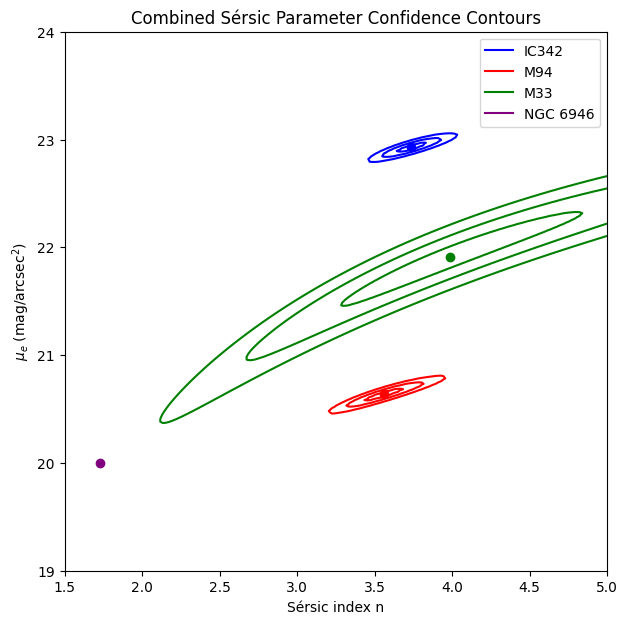

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
from scipy.special import gammaincinv


# Shared functions


r_e = 3.6

def c(n):
    return 2.5*(0.868*n - 0.142)

def sersic_model(r, n, Mu_e):
    return Mu_e + c(n)*((r/r_e)**(1/n) - 1)

def fit_sersic(r, Mu, err):

    popt, pcov = curve_fit(
        sersic_model,
        r,
        Mu,
        sigma=err,
        absolute_sigma=True,
        p0=[1.0,24],
        bounds=([0.1,20],[10,30])
    )

    return popt

def compute_contour(r, Mu, err, n_axis, Mu_axis):

    N_grid, MU_grid = np.meshgrid(n_axis, Mu_axis)
    chi2_grid = np.zeros_like(N_grid)

    for i in range(len(n_axis)):
        for j in range(len(Mu_axis)):

            model = sersic_model(r, N_grid[j,i], MU_grid[j,i])
            chi2_grid[j,i] = np.sum(((Mu - model)/err)**2)

    delta = chi2_grid - np.min(chi2_grid)

    return delta


# IC342 DATA

R = np.array([0.2, 6.8, 10.1, 16.6, 19.9, 23.2, 29.8, 36.4, 42.9])
R = R * 0.9117

C = np.array([307.29, 89490, 0.15729e6, 0.35735e6, 0.49164e6,
              0.64865e6, 0.10319e7, 0.15089e7, 0.20724e7])

D = C - (0.41947e6)/(np.pi*19.92**2) * (R**2 * np.pi)

M = -2.5*np.log10(D) + 24.646
Mu_IC342 = M + 2.5*np.log10(np.pi*R**2)

M_err_IC342 = np.sqrt(((2.5/np.log(10))*(np.sqrt(C)/D))**2 + 0.0042)

Distance = 3300
r_IC342 = R * Distance / 206265


# M94 DATA

R = np.array([6.8,16.7,23.2,36.4,46.3,3.5,10.1,29.8])
R = R * 0.9117

C = np.array([0.47387e6,0.16e7,0.25470e7,0.49156e7,
              0.7218e7,0.16307e6,0.83097e6,0.36347e7])

D = C - (0.21098e7)/(np.pi*29.8**2) * (R**2 * np.pi)

M = -2.5*np.log10(D) + 24.646
Mu_M94 = M + 2.5*np.log10(np.pi*R**2)

M_err_M94 = np.sqrt(((2.5/np.log(10))*(np.sqrt(C)/D))**2 + 0.0042)

r_M94 = R * Distance / 206265


# M33 DATA

R = np.array([5.7,10.7,15.7,20.7,25.7,30.7,35.7,40.7,45.7,50.7])
R = R * 0.9117

C = np.array([0.49327e6,0.1326e7,0.25072e7,0.40487e7,
              0.59545e7,0.82233e7,0.10862e8,0.13873e8,
              0.1725e8,0.20999e8])

D = C - (0.21117e7)/(np.pi*16.7**2) * (R**2 * np.pi)

M = -2.5*np.log10(D) + 24.582
Mu_M33 = M + 2.5*np.log10(np.pi*R**2)

M_err_M33 = np.sqrt(((2.5/np.log(10))*(np.sqrt(C)/D))**2 + 0.101)

Distance_M33 = 840
r_M33 = R * Distance_M33 / 206265


# NGC6946 DATA

Semimajor_axis = np.array([5.2,10.2,15.2,20.2,25.2,30.2,
                           35.2,40.2,45.2,50.2,55.2])

Semimajor_axis *= 0.9117

C = np.array([0.17211e6,0.59525e6,0.12696e7,0.21976e7,
              0.33796e7,0.48159e7,0.6499e7,0.84342e7,
              0.10624e8,0.13065e8,0.15757e8])

C_ann = np.empty_like(C)
C_ann[0] = C[0]
C_ann[1:] = np.diff(C)

Area_ann = np.empty_like(C)
Area_ann[0] = np.pi*Semimajor_axis[0]**2
Area_ann[1:] = np.pi*np.diff(Semimajor_axis**2)

sky = 0.13788e7/(np.pi*16.7**2)

D_ann = C_ann - sky*Area_ann

Mu_original = -2.5*np.log10(D_ann/Area_ann) + 24.646

Mag_err = np.sqrt(((2.5/np.log(10))*(np.sqrt(C_ann)/D_ann))**2 + 0.004**2)

r_mid = np.empty_like(Semimajor_axis)
r_mid[0] = Semimajor_axis[0]/2
r_mid[1:] = (Semimajor_axis[1:] + Semimajor_axis[:-1])/2

Distance_6946 = 7720
r_6946 = r_mid * Distance_6946 / 206265

r_6946 = r_6946[1:]
Mu_6946 = Mu_original[1:]
err_6946 = Mag_err[1:]


# Fit galaxies

best_n_IC342, best_Mu_e_IC342 = fit_sersic(r_IC342,Mu_IC342,M_err_IC342)
best_n_M94, best_Mu_e_M94 = fit_sersic(r_M94,Mu_M94,M_err_M94)
best_n_M33, best_Mu_e_M33 = fit_sersic(r_M33,Mu_M33,M_err_M33)
best_n_6946, best_Mu_e_6946 = fit_sersic(r_6946,Mu_6946,err_6946)


# Parameter space

n_axis = np.linspace(1.5,5,200)
Mu_axis = np.linspace(19,24,200)

N_grid, MU_grid = np.meshgrid(n_axis,Mu_axis)


# Contours

delta_IC342 = compute_contour(r_IC342,Mu_IC342,M_err_IC342,n_axis,Mu_axis)
delta_M94 = compute_contour(r_M94,Mu_M94,M_err_M94,n_axis,Mu_axis)
delta_M33 = compute_contour(r_M33,Mu_M33,M_err_M33,n_axis,Mu_axis)
delta_6946 = compute_contour(r_6946,Mu_6946,err_6946,n_axis,Mu_axis)


# Plot

levels = [1,4,9]

plt.figure(figsize=(7,7))

plt.contour(N_grid,MU_grid,delta_IC342,levels=levels,colors='blue')
plt.contour(N_grid,MU_grid,delta_M94,levels=levels,colors='red')
plt.contour(N_grid,MU_grid,delta_M33,levels=levels,colors='green')
plt.contour(N_grid,MU_grid,delta_6946,levels=levels,colors='purple')

plt.plot(best_n_IC342,best_Mu_e_IC342,'bo')
plt.plot(best_n_M94,best_Mu_e_M94,'ro')
plt.plot(best_n_M33,best_Mu_e_M33,'go')
plt.plot(best_n_6946,best_Mu_e_6946,'o',color='purple')

plt.xlabel("Sérsic index n")
plt.ylabel(r"$\mu_e$ (mag/arcsec$^2$)")
plt.title("Combined Sérsic Parameter Confidence Contours")

legend_elements = [
    Line2D([0],[0],color='blue',label='IC342'),
    Line2D([0],[0],color='red',label='M94'),
    Line2D([0],[0],color='green',label='M33'),
    Line2D([0],[0],color='purple',label='NGC 6946')
]

plt.legend(handles=legend_elements)

plt.show()

Best-fit n = 3.216 ± 0.114
Best-fit Mu_e = 20.204 ± 0.054
Reduced Chi² = 0.588374507931122


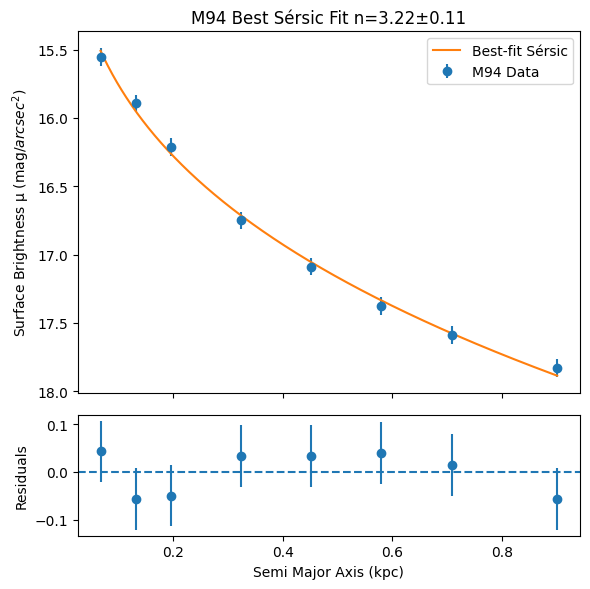

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize

# Data

R = np.array([6.8,16.7,23.2,36.4,46.3,3.5,10.1,29.8])
R = R * 0.9117

C = np.array([0.47387e6,0.16e7,0.25470e7,0.49156e7,0.7218e7,0.16307e6,0.83097e6,0.36347e7])

# Background subtraction
D = C - (0.21098e7)/(np.pi*29.8**2) * (R**2 * np.pi)

# Surface brightness
M = -2.5*np.log10(D) + 24.646
Mu = M + 2.5*np.log10(np.pi*R**2)

# Error propagation
M_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C)/D))**2 + 0.0042)

# Convert radius to physical units
Distance = 4400
r = R * Distance / 206265

# Sérsic parameters

r_e = 3.6

def c(n):
    return 2.5*(0.868*n - 0.142)

def sersic_model(r, n, Mu_e):
    return Mu_e + c(n)*((r/r_e)**(1/n) - 1)

# Fit

initial_guess = [1.0, 24]
bounds = ([0.1,20], [10,30])

popt, pcov = scipy.optimize.curve_fit(
    sersic_model,
    r,
    Mu,
    sigma=M_err,
    absolute_sigma=True,
    p0=initial_guess,
    bounds=bounds
)

best_n, best_Mu_e = popt

perr = np.sqrt(np.diag(pcov))
n_err, Mu_e_err = perr

# Reduced chi²

model_vals = sersic_model(r, best_n, best_Mu_e)

chi2 = np.sum(((Mu - model_vals)/M_err)**2)
dof = len(r) - 2
chi2_reduced = chi2/dof

print(f"Best-fit n = {best_n:.3f} ± {n_err:.3f}")
print(f"Best-fit Mu_e = {best_Mu_e:.3f} ± {Mu_e_err:.3f}")
print("Reduced Chi² =", chi2_reduced)

# Residuals

residuals = Mu - model_vals

# Smooth curve
# 

r_smooth = np.linspace(np.min(r), np.max(r), 500)
mu_fit = sersic_model(r_smooth, best_n, best_Mu_e)

# Plot (data + residuals)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(6,6),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Top plot: data + fit
ax1.errorbar(r, Mu, yerr=M_err, fmt='o', label='M94 Data')
ax1.plot(r_smooth, mu_fit, label='Best-fit Sérsic')

ax1.set_ylabel("Surface Brightness μ (mag/$arcsec^2$)")
ax1.invert_yaxis()
ax1.legend()
ax1.set_title(f"M94 Best Sérsic Fit n={best_n:.2f}±{n_err:.2f}")

# Bottom plot: residuals
ax2.axhline(0, linestyle='--')
ax2.errorbar(r, residuals, yerr=M_err, fmt='o')

ax2.set_xlabel("Semi Major Axis (kpc)")
ax2.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

Best-fit n = 3.736 ± 0.094
Best-fit Mu_e = 22.928 ± 0.044
Reduced Chi² = 8.825258804190165


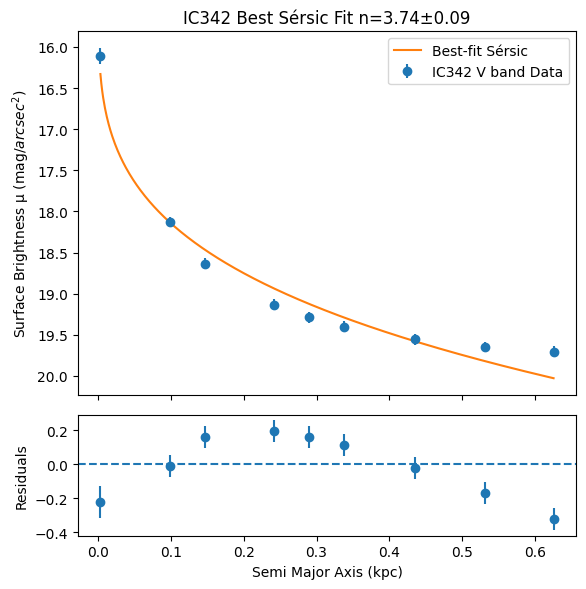

In [5]:
#IC342 V band
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize

# Data

R = np.array([0.2, 6.8, 10.1, 16.6, 19.9, 23.2, 29.8, 36.4, 42.9])
R = R * 0.9117

C = np.array([307.29, 89490, 0.15729e6, 0.35735e6, 0.49164e6,
              0.64865e6, 0.10319e7, 0.15089e7, 0.20724e7])

# Background subtraction
D = C - (0.41947e6)/(np.pi*19.92**2) * (R**2 * np.pi)

# Surface brightness
M = -2.5*np.log10(D) + 24.646
Mu = M + 2.5*np.log10(np.pi*R**2)

# Error propagation
M_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C)/D))**2 + 0.0042)

# Convert radius to physical units
Distance = 3300
r = R * Distance / 206265

# Sérsic parameters

r_e = 3.6

def c(n):
    return 2.5*(0.868*n - 0.142)

def sersic_model(r, n, Mu_e):
    return Mu_e + c(n)*((r/r_e)**(1/n) - 1)

# Fit

initial_guess = [1.0, 24]
bounds = ([0.1,20], [10,30])

popt, pcov = scipy.optimize.curve_fit(
    sersic_model,
    r,
    Mu,
    sigma=M_err,
    absolute_sigma=True,
    p0=initial_guess,
    bounds=bounds
)

best_n, best_Mu_e = popt

perr = np.sqrt(np.diag(pcov))
n_err, Mu_e_err = perr

# Reduced chi²

model_vals = sersic_model(r, best_n, best_Mu_e)

chi2 = np.sum(((Mu - model_vals)/M_err)**2)
dof = len(r) - 2
chi2_reduced = chi2/dof

print(f"Best-fit n = {best_n:.3f} ± {n_err:.3f}")
print(f"Best-fit Mu_e = {best_Mu_e:.3f} ± {Mu_e_err:.3f}")
print("Reduced Chi² =", chi2_reduced)

# Residuals

residuals = Mu - model_vals


# Smooth curve

r_smooth = np.linspace(np.min(r), np.max(r), 500)
mu_fit = sersic_model(r_smooth, best_n, best_Mu_e)

# Plot (data + residuals)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(6,6),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Top plot: data + fit
ax1.errorbar(r, Mu, yerr=M_err, fmt='o', label='IC342 V band Data')
ax1.plot(r_smooth, mu_fit, label='Best-fit Sérsic')

ax1.set_ylabel("Surface Brightness μ (mag/$arcsec^2$)")
ax1.invert_yaxis()
ax1.legend()
ax1.set_title(f"IC342 Best Sérsic Fit n={best_n:.2f}±{n_err:.2f}")

# Bottom plot: residuals
ax2.axhline(0, linestyle='--')
ax2.errorbar(r, residuals, yerr=M_err, fmt='o')

ax2.set_xlabel("Semi Major Axis (kpc)")
ax2.set_ylabel("Residuals")

plt.tight_layout()
plt.show()



Best-fit n = 0.573 ± 0.103
Best-fit Mu_e = 20.141 ± 0.201
Reduced Chi² = 3.1381830601006953


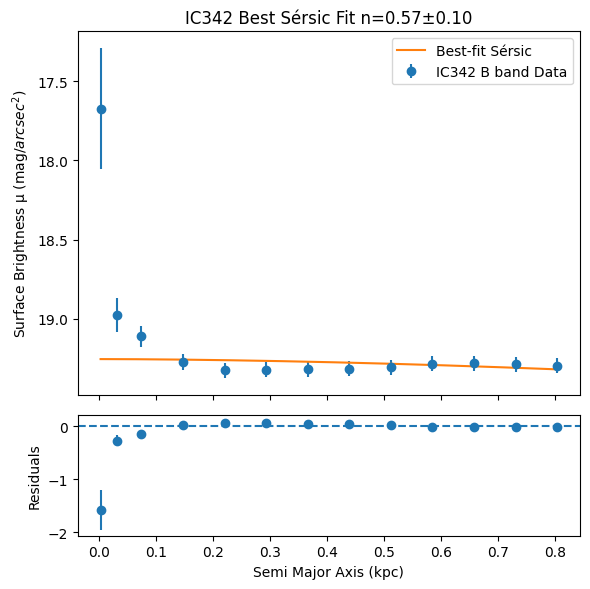

In [6]:
#IC342 B band
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize


# Data

R = np.array([0.2, 2.2, 5.1, 10.1, 15.1, 20.1, 25.1, 30.1, 35.1, 40.1, 45.1, 50.1, 55.1 ])
R = R * 0.9117

C = np.array([40.748, 3390.2 ,17801, 68103, 0.1511*10**6, 0.2679*10**6, 0.41799*10**6, 0.60137*10**6, 0.81867*10**6, 0.10719*10**7, 0.13563*10**7, 0.16724*10**7,  0.20205*10**7  ])

# Background subtraction
D = C - (0.2683*10**6)/(np.pi*19.9**2) * (R**2 * np.pi)

# Surface brightness
M = -2.5*np.log10(D) + 23.277
Mu = M + 2.5*np.log10(np.pi*R**2)

# Error propagation
M_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C)/D))**2 + 0.0021)

# Convert radius to physical units
Distance = 3300
r = R * Distance / 206265

# Sérsic parameters


r_e = 3.6

def c(n):
    return 2.5*(0.868*n - 0.142)

def sersic_model(r, n, Mu_e):
    return Mu_e + c(n)*((r/r_e)**(1/n) - 1)

# Fit

initial_guess = [1.0, 24]
bounds = ([0.1,20], [10,30])

popt, pcov = scipy.optimize.curve_fit(
    sersic_model,
    r,
    Mu,
    sigma=M_err,
    absolute_sigma=True,
    p0=initial_guess,
    bounds=bounds
)

best_n, best_Mu_e = popt

perr = np.sqrt(np.diag(pcov))
n_err, Mu_e_err = perr

# Reduced chi²

model_vals = sersic_model(r, best_n, best_Mu_e)

chi2 = np.sum(((Mu - model_vals)/M_err)**2)
dof = len(r) - 2
chi2_reduced = chi2/dof

print(f"Best-fit n = {best_n:.3f} ± {n_err:.3f}")
print(f"Best-fit Mu_e = {best_Mu_e:.3f} ± {Mu_e_err:.3f}")
print("Reduced Chi² =", chi2_reduced)

# Residuals

residuals = Mu - model_vals

# Smooth curve

r_smooth = np.linspace(np.min(r), np.max(r), 500)
mu_fit = sersic_model(r_smooth, best_n, best_Mu_e)

# Plot (data + residuals)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(6,6),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Top plot: data + fit
ax1.errorbar(r, Mu, yerr=M_err, fmt='o', label='IC342 B band Data')
ax1.plot(r_smooth, mu_fit, label='Best-fit Sérsic')

ax1.set_ylabel("Surface Brightness μ (mag/$arcsec^2$)")
ax1.invert_yaxis()
ax1.legend()
ax1.set_title(f"IC342 Best Sérsic Fit n={best_n:.2f}±{n_err:.2f}")

# Bottom plot: residuals
ax2.axhline(0, linestyle='--')
ax2.errorbar(r, residuals, yerr=M_err, fmt='o')

ax2.set_xlabel("Semi Major Axis (kpc)")
ax2.set_ylabel("Residuals")

plt.tight_layout()
plt.show()



Best-fit n = 3.558 ± 0.126
Best-fit Mu_e = 20.636 ± 0.059
Reduced Chi² = 0.589941026380414


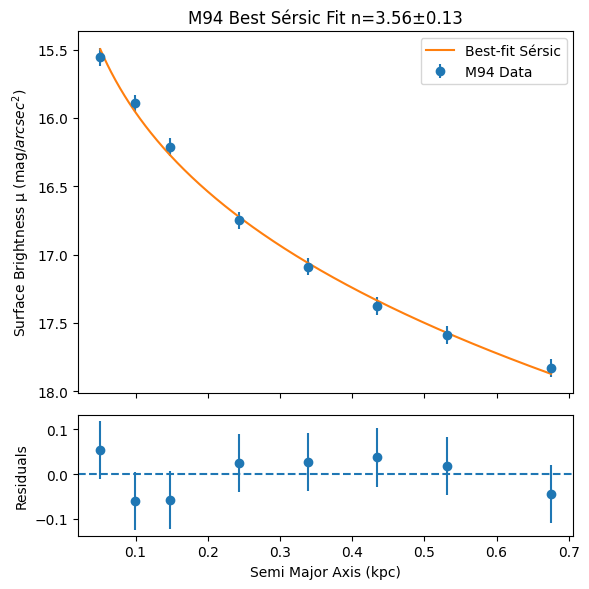

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize

# Data

R = np.array([6.8,16.7,23.2,36.4,46.3,3.5,10.1,29.8])
R = R * 0.9117

C = np.array([0.47387e6,0.16e7,0.25470e7,0.49156e7,0.7218e7,0.16307e6,0.83097e6,0.36347e7])

# Background subtraction
D = C - (0.21098e7)/(np.pi*29.8**2) * (R**2 * np.pi)

# Surface brightness
M = -2.5*np.log10(D) + 24.646
Mu = M + 2.5*np.log10(np.pi*R**2)

# Error propagation
M_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C)/D))**2 + 0.0042)

# Convert radius to physical units
Distance = 3300
r = R * Distance / 206265

 
# Sérsic parameters

r_e = 3.6

def c(n):
    return 2.5*(0.868*n - 0.142)

def sersic_model(r, n, Mu_e):
    return Mu_e + c(n)*((r/r_e)**(1/n) - 1)


# Fit

initial_guess = [1.0, 24]
bounds = ([0.1,20], [10,30])

popt, pcov = scipy.optimize.curve_fit(
    sersic_model,
    r,
    Mu,
    sigma=M_err,
    absolute_sigma=True,
    p0=initial_guess,
    bounds=bounds
)

best_n, best_Mu_e = popt

perr = np.sqrt(np.diag(pcov))
n_err, Mu_e_err = perr

# Reduced chi²

model_vals = sersic_model(r, best_n, best_Mu_e)

chi2 = np.sum(((Mu - model_vals)/M_err)**2)
dof = len(r) - 2
chi2_reduced = chi2/dof

print(f"Best-fit n = {best_n:.3f} ± {n_err:.3f}")
print(f"Best-fit Mu_e = {best_Mu_e:.3f} ± {Mu_e_err:.3f}")
print("Reduced Chi² =", chi2_reduced)

# Residuals

residuals = Mu - model_vals

# Smooth curve

r_smooth = np.linspace(np.min(r), np.max(r), 500)
mu_fit = sersic_model(r_smooth, best_n, best_Mu_e)

# Plot (data + residuals)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(6,6),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Top plot: data + fit
ax1.errorbar(r, Mu, yerr=M_err, fmt='o', label='M94 Data')
ax1.plot(r_smooth, mu_fit, label='Best-fit Sérsic')

ax1.set_ylabel("Surface Brightness μ (mag/$arcsec^2$)")
ax1.invert_yaxis()
ax1.legend()
ax1.set_title(f"M94 Best Sérsic Fit n={best_n:.2f}±{n_err:.2f}")

# Bottom plot: residuals
ax2.axhline(0, linestyle='--')
ax2.errorbar(r, residuals, yerr=M_err, fmt='o')

ax2.set_xlabel("Semi Major Axis (kpc)")
ax2.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

Best-fit Sérsic index   n    = 4.0499
Best-fit eff. SB        Mu_e = 25.8441 mag/arcsec²
Chi²                         = 190.8778
Reduced chi² (chi²/dof)      = 27.2683  (dof=7)
→ n > 2.5: significant bulge → likely merger contribution


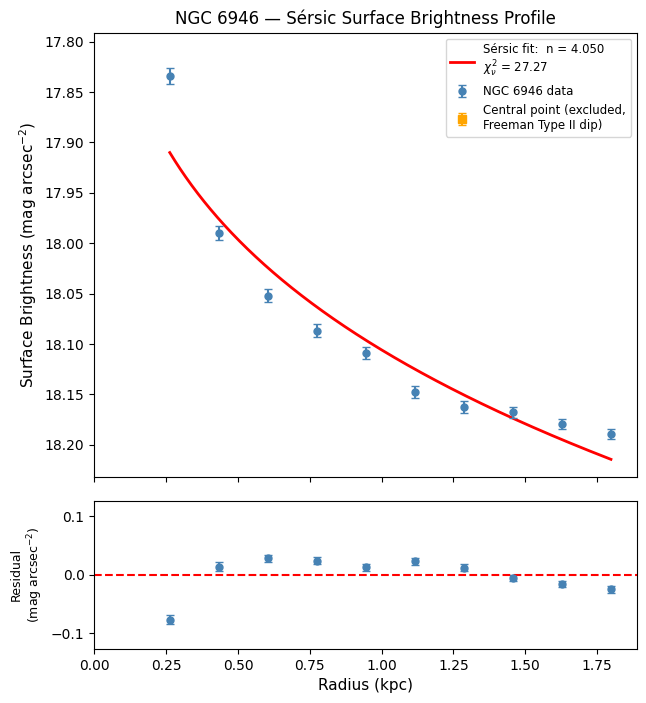

In [23]:
# NGC6946
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaincinv

# Raw data 
Semimajor_axis = np.array([5.2, 10.2, 15.2, 20.2, 25.2, 30.2,
                            35.2, 40.2, 45.2, 50.2, 55.2])
Semimajor_axis *= 0.9117

C = np.array([0.17211e6, 0.59525e6, 0.12696e7, 0.21976e7, 0.33796e7,
              0.48159e7, 0.6499e7,  0.84342e7, 0.10624e8, 0.13065e8, 0.15757e8])

# Annular counts to local surface brightness 
C_ann        = np.empty_like(C);  C_ann[0]  = C[0];  C_ann[1:]  = np.diff(C)
Area_ann     = np.empty_like(C);  Area_ann[0] = np.pi * Semimajor_axis[0]**2
Area_ann[1:] = np.pi * np.diff(Semimajor_axis**2)

sky_per_arcsec2 = 0.13788e7 / (np.pi * 16.7**2)
D_ann           = C_ann - sky_per_arcsec2 * Area_ann

Mu_original = -2.5 * np.log10(D_ann / Area_ann) + 24.646
Mag_err     = np.sqrt(((2.5 / np.log(10)) * (np.sqrt(C_ann) / D_ann))**2 + 0.004**2)
w           = 1.0 / Mag_err**2

r_mid        = np.empty_like(Semimajor_axis)
r_mid[0]     = Semimajor_axis[0] / 2.0
r_mid[1:]    = (Semimajor_axis[1:] + Semimajor_axis[:-1]) / 2.0

Distance = 7720   # kpc (7.72 Mpc, literature)
r        = r_mid * Distance / 206265

# Exclude central Freeman Type II point
r_fit  = r[1:];  Mu_fit = Mu_original[1:];  w_fit = w[1:];  e_fit = Mag_err[1:]

# Reparameterised Sérsic fit 
def b_n(n):
    return gammaincinv(2.0 * n, 0.5)

def wls_fit(n, r_fit, Mu_fit, w_fit):
    """For a given n, solve WLS analytically. Returns A, B, chi2."""
    x    = r_fit ** (1.0 / n)
    Sw   = np.sum(w_fit);        Swx  = np.sum(w_fit * x)
    Swx2 = np.sum(w_fit * x**2); Swy  = np.sum(w_fit * Mu_fit)
    Swxy = np.sum(w_fit * x * Mu_fit)
    denom = Sw * Swx2 - Swx**2
    B = (Sw * Swxy - Swx * Swy) / denom
    A = (Swy - B * Swx) / Sw
    chi2 = np.sum(w_fit * (Mu_fit - A - B * x)**2)
    return A, B, chi2

# Stage 1: coarse search 
best_chi2 = np.inf;  best_n = None
for n in np.arange(0.5, 4.0, 0.05):
    A, B, chi2 = wls_fit(n, r_fit, Mu_fit, w_fit)
    if B > 0 and chi2 < best_chi2:
        best_chi2 = chi2;  best_n = n

# Stage 2: fine search ± 0.1 around best coarse n 
best_chi2 = np.inf
for n in np.arange(best_n - 0.1, best_n + 0.1, 0.0001):
    A, B, chi2 = wls_fit(n, r_fit, Mu_fit, w_fit)
    if B > 0 and chi2 < best_chi2:
        best_chi2 = chi2;  best_n = n;  best_A = A;  best_B = B

# Recover physical parameters 
bn        = b_n(best_n)
best_Mu_e = best_A + 2.5 * bn / np.log(10)
best_r_e  = (2.5 * bn / (np.log(10) * best_B)) ** best_n

dof          = len(r_fit) - 3
reduced_chi2 = best_chi2 / dof

print(f"Best-fit Sérsic index   n    = {best_n:.4f}")
print(f"Best-fit eff. SB        Mu_e = {best_Mu_e:.4f} mag/arcsec²")
print(f"Chi²                         = {best_chi2:.4f}")
print(f"Reduced chi² (chi²/dof)      = {reduced_chi2:.4f}  (dof={dof})")

if best_n <= 1.5:
    print("→ n ≈ 1: pure exponential disc → gas accretion dominated")
elif best_n <= 2.5:
    print("→ n ~ 1.5–2.5: disc + bulge blend → some merger contribution")
else:
    print("→ n > 2.5: significant bulge → likely merger contribution")

# Plot 
def sersic(r, n, A, B):
    return A + B * r**(1.0/n)

r_smooth   = np.linspace(r_fit.min(), r_fit.max(), 500)
fit_smooth = sersic(r_smooth, best_n, best_A, best_B)
residuals  = Mu_fit - sersic(r_fit, best_n, best_A, best_B)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8),
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08},
                                sharex=True)

ax1.errorbar(r_fit, Mu_fit, yerr=e_fit, fmt='o', markersize=5,
             capsize=3, color='steelblue', label='NGC 6946 data', zorder=3)
ax1.errorbar(r[0:1], Mu_original[0:1], yerr=Mag_err[0:1], fmt='s', markersize=6,
             capsize=3, color='orange', label='Central point (excluded,\nFreeman Type II dip)')
ax1.plot(r_smooth, fit_smooth, 'r-', lw=2,
         label=f'Sérsic fit:  n = {best_n:.3f}\n'
               f'$\\chi^2_{{\\nu}}$ = {reduced_chi2:.2f}')
ax1.axvline(best_r_e, color='grey', ls='--', lw=1, alpha=0.7,)

ax1.invert_yaxis()
pad = (Mu_fit.max() - Mu_fit.min()) * 0.12
ax1.set_ylim(Mu_fit.max() + pad, Mu_fit.min() - pad)
ax1.set_xlim(0, r.max() * 1.05)
ax1.set_ylabel("Surface Brightness (mag arcsec$^{-2}$)", fontsize=11)
ax1.set_title("NGC 6946 — Sérsic Surface Brightness Profile", fontsize=12)
ax1.legend(fontsize=8.5, loc='upper right')


ax2.errorbar(r_fit, residuals, yerr=e_fit, fmt='o', markersize=5,
             capsize=3, color='steelblue')
ax2.axhline(0, color='r', ls='--', lw=1.5)
res_pad = (abs(residuals).max() + e_fit.max()) * 1.5
ax2.set_ylim(-res_pad, res_pad)
ax2.set_xlabel("Radius (kpc)", fontsize=11)
ax2.set_ylabel("Residual\n(mag arcsec$^{-2}$)", fontsize=9)


plt.savefig("NGC6946_sersic.png", dpi=150, bbox_inches='tight')
plt.show()

Best-fit Sérsic index n = 7.950000000000006
Best-fit vertical shift i = -5.299999999999933
Minimum chi^2 = 209693.7146577569


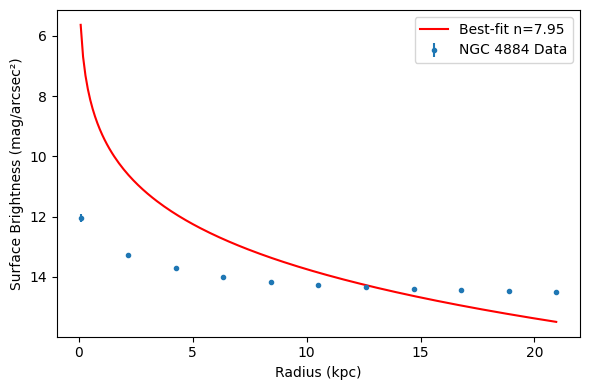

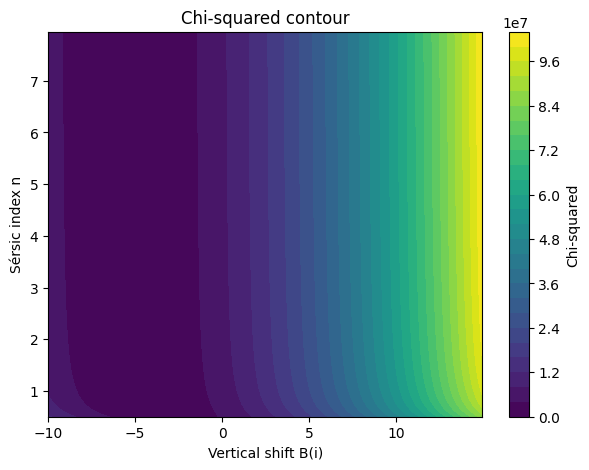

In [9]:
#NGC 4884
import numpy as np
import matplotlib.pyplot as plt


Semimajor_axis = np.array([0.2, 5.2, 10.2, 15.2, 20.2, 25.2, 30.2, 35.2, 40.2, 45.2, 50.2  ]) #change per galaxy
Semimajor_axis *= 0.9117

C = np.array([141.99, 50114, 0.16412*10**6, 0.33606*10**6, 0.57067*10**6, 0.86703*10**6, 0.12266*10**7, 0.16480*10**7, 0.21318*10**7, 0.26843*10**7, 0.32986*10**7   ]) #change per galaxy

D = C - (0.42706*10**6)/(np.pi*18.4**2) * (Semimajor_axis**2 * np.pi) #change terms for counts in sky area and radius of circle

Magnitude = -2.5*np.log10(D) + 24.788 #change zero point
Mu_original = Magnitude + 2.5*np.log10(np.pi*Semimajor_axis**2)
Mag_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C)/D))**2 + 0.004**2)

Distance = 94433 #change distance to galaxy in kpc
r = Semimajor_axis * Distance / 206265  


r_e = 6.2 #change half light radius
Mu_e = 12.7 #change surface brightness 

def c(n):
    return 2.5 * (0.868*n - 0.142)

def sersic_model(r, n):
    return Mu_e + c(n) * ((r/r_e)**(1/n) - 1)


n_values = np.arange(0.5, 8.0, 0.05)   
i_values = np.arange(-10.0, 15.0, 0.05)  

chi_grid = np.zeros((len(n_values), len(i_values)))

for a, n in enumerate(n_values):
    for b, i in enumerate(i_values):
        Expected = sersic_model(r, n)
        Mu_shifted = Mu_original + i
        chi = np.sum((Mu_shifted - Expected)**2 / Mag_err**2)
        chi_grid[a, b] = chi


best_index = np.unravel_index(np.argmin(chi_grid), chi_grid.shape)
best_n = n_values[best_index[0]]
best_i = i_values[best_index[1]]
best_chi = chi_grid[best_index]

print("Best-fit Sérsic index n =", best_n)
print("Best-fit vertical shift i =", best_i)
print("Minimum chi^2 =", best_chi)

plt.figure(figsize=(6,4))
plt.errorbar(r, Mu_original + best_i, yerr=Mag_err, markersize=3, fmt='o', label='NGC 4884 Data') # change name 
r_smooth = np.linspace(min(r), max(r), 200)
plt.plot(r_smooth, sersic_model(r_smooth, best_n), 'r-', label=f'Best-fit n={best_n:.2f}')
plt.gca().invert_yaxis()
plt.xlabel("Radius (kpc)")
plt.ylabel("Surface Brightness (mag/arcsec²)")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
X, Y = np.meshgrid(i_values, n_values)
plt.contourf(X, Y, chi_grid, levels=30, cmap='viridis')
plt.colorbar(label='Chi-squared')
plt.xlabel("Vertical shift B(i)")
plt.ylabel("Sérsic index n")
plt.title("Chi-squared contour")
plt.show()

Best-fit Sérsic index n = 7.950000000000006
Best-fit vertical shift i = -5.09999999999993
Minimum chi^2 = 514810.96467119514


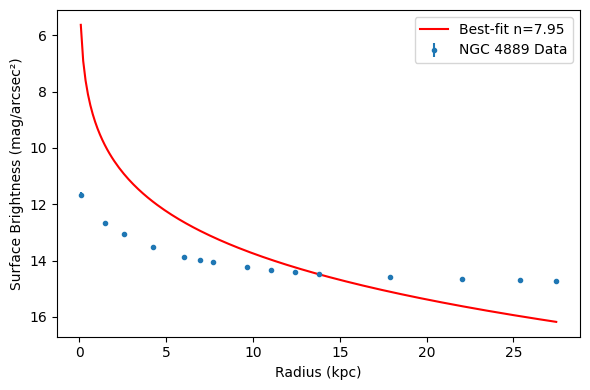

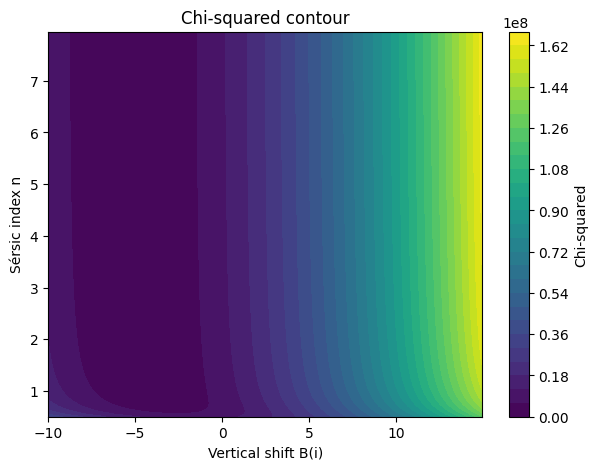

In [10]:
#NGC 4889
import numpy as np
import matplotlib.pyplot as plt


Semimajor_axis = np.array([6.1, 10.1, 16.7, 23.2, 0.2, 3.5, 14.4, 18.4, 26.5, 29.8, 33.1, 42.9, 52.8, 60.8,  65.8,  ]) #change per galaxy
Semimajor_axis *= 0.9117

C = np.array([82007, 0.1846*10**6, 0.43071*10**6, 0.78039*10**6, 212.16, 33705, 0.33185*10**6, 0.512223*10**6, 0.99174*10**6, 0.12324*10**7, 0.14992*10**7, 0.24574*10**7, 0.368432*10**7, 0.48463*10**7, 0.56476*10**7,   ]) #change per galaxy

D = C - (0.42706*10**6)/(np.pi*18.4**2) * (Semimajor_axis**2 * np.pi) #change terms for counts in sky area and radius of circle

Magnitude = -2.5*np.log10(D) + 24.788 #change zero point
Mu_original = Magnitude + 2.5*np.log10(np.pi*Semimajor_axis**2)
Mag_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C)/D))**2 + 0.004**2)
Distance = 94433 #change distance to galaxy in kpc
r = Semimajor_axis * Distance / 206265  


r_e = 6.2 #change half light radius
Mu_e = 12.7 #change surface brightness 

def c(n):
    return 2.5 * (0.868*n - 0.142)

def sersic_model(r, n):
    return Mu_e + c(n) * ((r/r_e)**(1/n) - 1)


n_values = np.arange(0.5, 8.0, 0.05)   
i_values = np.arange(-10.0, 15.0, 0.05)  

chi_grid = np.zeros((len(n_values), len(i_values)))

for a, n in enumerate(n_values):
    for b, i in enumerate(i_values):
        Expected = sersic_model(r, n)
        Mu_shifted = Mu_original + i
        chi = np.sum((Mu_shifted - Expected)**2 / Mag_err**2)
        chi_grid[a, b] = chi


best_index = np.unravel_index(np.argmin(chi_grid), chi_grid.shape)
best_n = n_values[best_index[0]]
best_i = i_values[best_index[1]]
best_chi = chi_grid[best_index]

print("Best-fit Sérsic index n =", best_n)
print("Best-fit vertical shift i =", best_i)
print("Minimum chi^2 =", best_chi)

plt.figure(figsize=(6,4))
plt.errorbar(r, Mu_original + best_i, yerr=Mag_err, markersize=3, fmt='o', label='NGC 4889 Data') # change name 
r_smooth = np.linspace(min(r), max(r), 200)
plt.plot(r_smooth, sersic_model(r_smooth, best_n), 'r-', label=f'Best-fit n={best_n:.2f}')
plt.gca().invert_yaxis()
plt.xlabel("Radius (kpc)")
plt.ylabel("Surface Brightness (mag/arcsec²)")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
X, Y = np.meshgrid(i_values, n_values)
plt.contourf(X, Y, chi_grid, levels=30, cmap='viridis')
plt.colorbar(label='Chi-squared')
plt.xlabel("Vertical shift B(i)")
plt.ylabel("Sérsic index n")
plt.title("Chi-squared contour")
plt.show()

Best-fit Sérsic index n = 3.4000000000000026
Best-fit vertical shift i = 7.950000000000008
Minimum chi^2 = 74147.76338365459


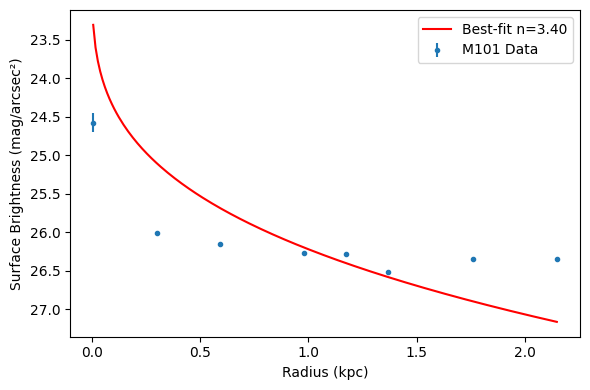

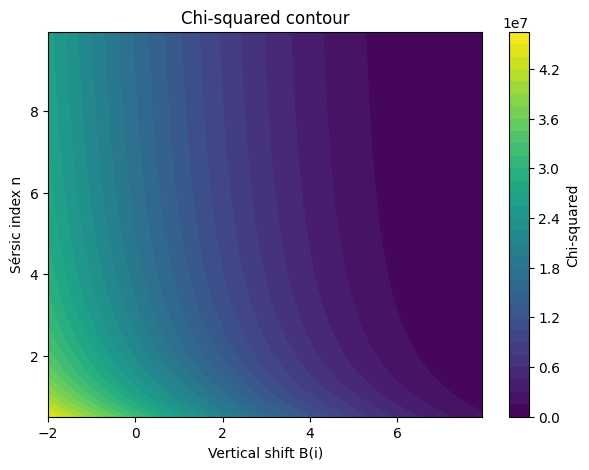

In [11]:
#M101

Semimajor_axis = np.array([0.2, 10.1, 19.9, 33.1, 39.6, 46.2, 59.4, 72.5])
Semimajor_axis *= 0.9117

C = np.array([195.64, 0.27798*10**6, 0.10408*10**7, 0.28027*10**7, 0.40023*10**7, 0.5191*10**7, 0.88922*10**7, 0.13214*10**8])
D = (C - (0.16393*10**7)/(np.pi*26.5**2) * (Semimajor_axis**2 * np.pi))

Magnitude = -2.5*np.log10(D) + 24.257 
Mu_original = Magnitude + 2.5*np.log10(np.pi*Semimajor_axis**2)
Mag_err = np.sqrt(((2.5/np.log(10)) * (np.sqrt(C)/D))**2 + 0.004**2)
Distance = 6700
r = Semimajor_axis * Distance / 206265  


r_e = 8.5
Mu_e = 29.5

def c(n):
    return 2.5 * (0.868*n - 0.142)

def sersic_model(r, n):
    return Mu_e + c(n) * ((r/r_e)**(1/n) - 1)


n_values = np.arange(0.5, 10.0, 0.05)   
i_values = np.arange(-2.0, 8.0, 0.05)  

chi_grid = np.zeros((len(n_values), len(i_values)))

for a, n in enumerate(n_values):
    for b, i in enumerate(i_values):
        Expected = sersic_model(r, n)
        Mu_shifted = Mu_original + i
        chi = np.sum((Mu_shifted - Expected)**2 / Mag_err**2)
        chi_grid[a, b] = chi


best_index = np.unravel_index(np.argmin(chi_grid), chi_grid.shape)
best_n = n_values[best_index[0]]
best_i = i_values[best_index[1]]
best_chi = chi_grid[best_index]

print("Best-fit Sérsic index n =", best_n)
print("Best-fit vertical shift i =", best_i)
print("Minimum chi^2 =", best_chi)

plt.figure(figsize=(6,4))
plt.errorbar(r, Mu_original + best_i, yerr=Mag_err, markersize=3, fmt='o', label='M101 Data')
r_smooth = np.linspace(min(r), max(r), 200)
plt.plot(r_smooth, sersic_model(r_smooth, best_n), 'r-', label=f'Best-fit n={best_n:.2f}')
plt.gca().invert_yaxis()
plt.xlabel("Radius (kpc)")
plt.ylabel("Surface Brightness (mag/arcsec²)")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
X, Y = np.meshgrid(i_values, n_values)
plt.contourf(X, Y, chi_grid, levels=30, cmap='viridis')
plt.colorbar(label='Chi-squared')
plt.xlabel("Vertical shift B(i)")
plt.ylabel("Sérsic index n")
plt.title("Chi-squared contour")
plt.show()